#LAB SHEET-1

1. Build a tool that loads an image in (JPG/PNG/BMP) format and displays its key properties, including its dimensions, number of channels, data type, and file size.

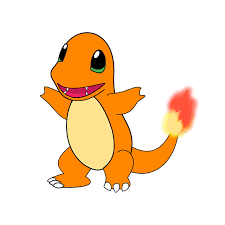

Image Properties
-------------------------
Format              : PNG
Dimensions          : 225 x 225
Number of Channels  : 1
Data Type           : uint8
File Size           : 5.54 KB


In [ ]:
from PIL import Image
import numpy as np
import os

image_path = "/content/charmendar.png"

img = Image.open(image_path)
img_array = np.array(img)
width, height = img.size
if len(img_array.shape) == 2:
    channels = 1
else:
    channels = img_array.shape[2]
file_size = os.path.getsize(image_path)

display(img)

print("Image Properties")
print("-------------------------")
print("Format              :", img.format)
print("Dimensions          :", width, "x", height)
print("Number of Channels  :", channels)
print("Data Type           :", img_array.dtype)
print("File Size           :", round(file_size / 1024, 2), "KB")

2. Create a program that reads a color image, converts it to grayscale, and displays both versions side by side for visual comparison.

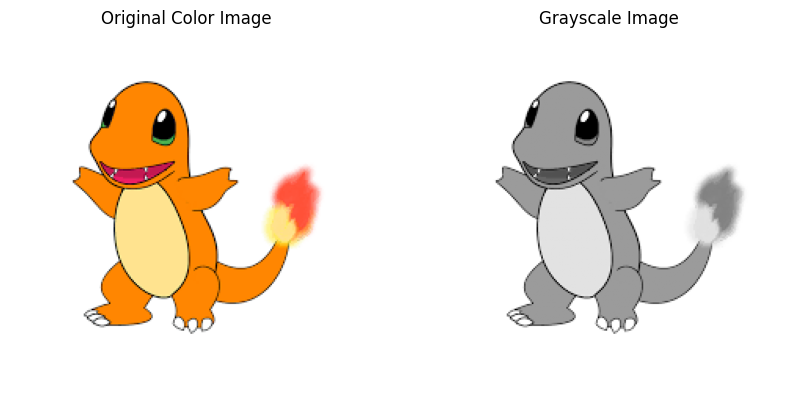

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "/content/charmendar.png"
color_image = Image.open(image_path)
gray_image = color_image.convert("L")
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(color_image)
plt.title("Original Color Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

3. Develop an image format converter that takes a single input image, exports it simultaneously as JPG, PNG, and BMP, and compares the resulting file sizes.

In [ ]:
from PIL import Image
import os

image_path = "/content/charmendar.png"
img = Image.open(image_path)
img = img.convert("RGB")
img.save("/content/output.jpg", "JPEG")
img.save("/content/output.png", "PNG")
img.save("/content/output.bmp", "BMP")
jpg_size = os.path.getsize("/content/output.jpg")
png_size = os.path.getsize("/content/output.png")
bmp_size = os.path.getsize("/content/output.bmp")
print("Image Format Comparison")
print("JPEG :", round(jpg_size / 1024, 2), "KB")
print("PNG  :", round(png_size / 1024, 2), "KB")
print("BMP  :", round(bmp_size / 1024, 2), "KB")

sizes = {
    "JPEG": jpg_size,
    "PNG": png_size,
    "BMP": bmp_size
}

smallest = min(sizes, key=sizes.get)

print("\nSmallest file:", smallest)

Image Format Comparison
JPEG : 6.32 KB
PNG  : 12.48 KB
BMP  : 148.59 KB

Smallest file: JPEG


4. Build a photo negative generator that computes and displays the color complement of an uploaded image.

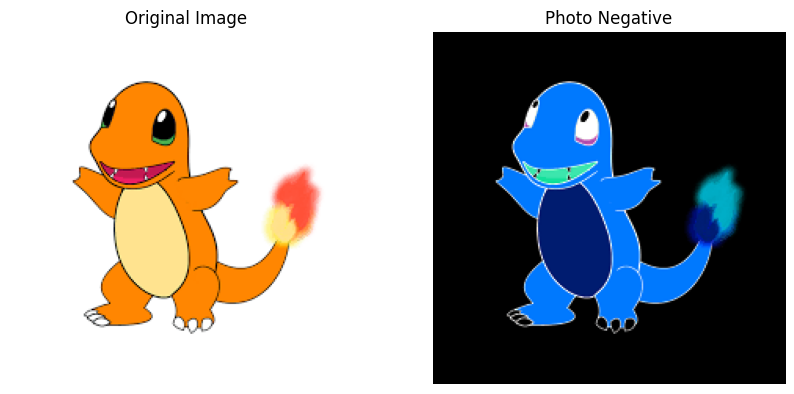

In [ ]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

image_path = "/content/charmendar.png"
img = Image.open(image_path).convert("RGB")
negative = ImageOps.invert(img)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(negative)
plt.title("Photo Negative")
plt.axis("off")
plt.show()

5. Create a batch image resizer that reads multiple images from a folder and saves resized copies while preserving their aspect ratios.

In [ ]:
from PIL import Image
import os

input_folder = "/content"
output_folder = "/content/resized_images"
os.makedirs(output_folder, exist_ok=True)
max_width = 800
max_height = 600
for filename in os.listdir(input_folder):
    if filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
        input_path = os.path.join(input_folder, filename)

        img = Image.open(input_path)
        img.thumbnail((max_width, max_height))

        output_path = os.path.join(output_folder, filename)
        img.save(output_path)

        print("Resized:", filename)

print("All images resized successfully!")

Resized: charmendar.png
Resized: output.bmp
Resized: watermarked_image.jpg
Resized: output.png
Resized: output.jpg
Resized: cropped_image.png
All images resized successfully!


6. Develop a program that crops a user-specified region of interest (ROI) from an image and saves the cropped region as a separate file.

Enter starting X coordinate: 35
Enter starting Y coordinate: 35
Enter ending X coordinate: 150
Enter ending Y coordinate: 150


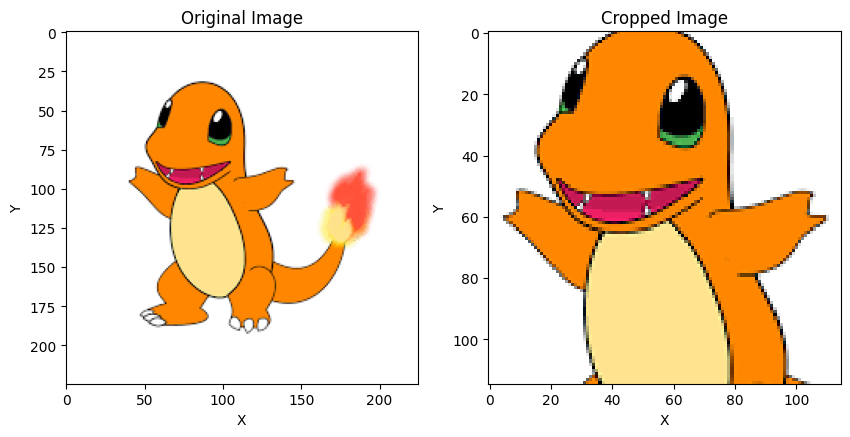

Cropped image saved 


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "/content/charmendar.png"
img = Image.open(image_path)
x1 = int(input("Enter starting X coordinate: "))
y1 = int(input("Enter starting Y coordinate: "))
x2 = int(input("Enter ending X coordinate: "))
y2 = int(input("Enter ending Y coordinate: "))
cropped = img.crop((x1, y1, x2, y2))
cropped.save("/content/cropped_image.png")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.xlabel("X")
plt.ylabel("Y")

plt.subplot(1, 2, 2)
plt.imshow(cropped)
plt.title("Cropped Image")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

print("Cropped image saved ")

7. Build a tool that splits an image into its individual Red, Green, and Blue (RGB) channels, reconstructs the original image from these channels, and verifies pixel-level accuracy between the original and reconstructed images.

Pixel Accuracy: True


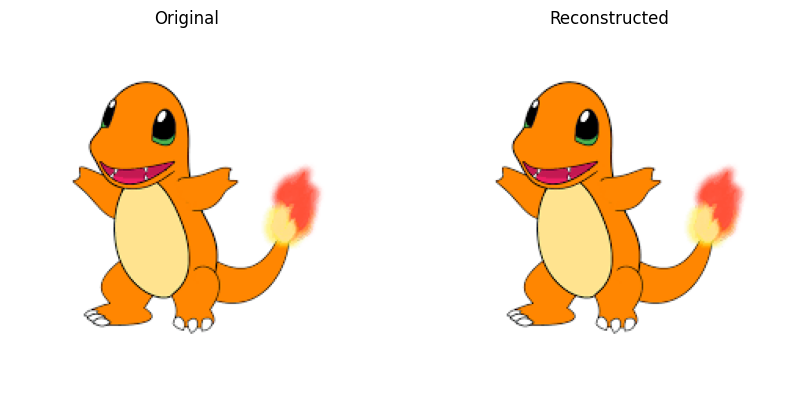

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = np.array(Image.open("/content/charmendar.png").convert("RGB"))

R, G, B = img[:, :, 0], img[:, :, 1], img[:, :, 2]

reconstructed = np.stack([R, G, B], axis=2)

print("Pixel Accuracy:", np.array_equal(img, reconstructed))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed)
plt.title("Reconstructed")
plt.axis("off")

plt.show()

8. Create a watermark utility that overlays a logo or text on an image and saves the watermarked output.

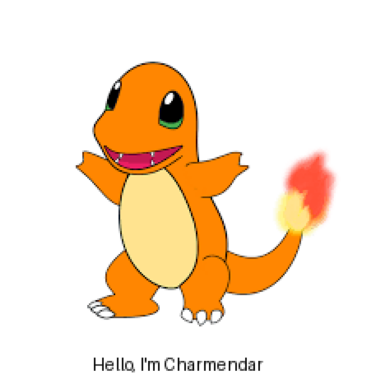

In [ ]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

image_path = "/content/charmendar.png"
img = Image.open(image_path).convert("RGB")

draw = ImageDraw.Draw(img)
draw.text((50, 210), "Hello, I'm Charmendar", fill="black")

img.save("/content/watermarked_image.jpg")

plt.imshow(img)
plt.axis("off")
plt.show()

9. Develop a program to rotate and flip an image by user-defined angles and directions, saving all transformed versions.

Enter rotation angle: 90
Enter flip direction (horizontal/vertical): vertical


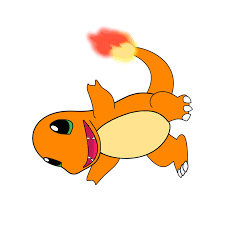

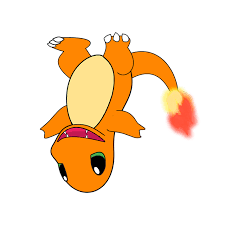

Transformed images saved successfully!


In [ ]:
from PIL import Image

image_path = "/content/charmendar.png"

img = Image.open(image_path).convert("RGB")

angle = float(input("Enter rotation angle: "))

direction = input("Enter flip direction (horizontal/vertical): ").lower()

rotated = img.rotate(angle, expand=True)

if direction == "horizontal":
    flipped = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
elif direction == "vertical":
    flipped = img.transpose(Image.Transpose.FLIP_TOP_BOTTOM)
else:
    print("Invalid direction")
    flipped = img

rotated.save("/content/rotated_image.jpg")
flipped.save("/content/flipped_image.jpg")

display(rotated)
display(flipped)

print("Transformed images saved successfully!")

10. Build a simple image metadata viewer that extracts EXIF data(if present) along with basic pixel statistics(mean, minimum, maximum).

In [ ]:
from PIL import Image, ExifTags
import numpy as np

image_path = "/content/charmendar.png"

img = Image.open(image_path)
arr = np.array(img)

print("Image Metadata")
print("Format:", img.format)
print("Dimensions:", img.size)
print("Mode:", img.mode)

print("\nPixel Statistics")
print("Mean:", arr.mean())
print("Minimum:", arr.min())
print("Maximum:", arr.max())

print("\nEXIF Data")
exif = img.getexif()

if exif:
    for key, value in exif.items():
        tag = ExifTags.TAGS.get(key, key)
        print(f"{tag}: {value}")
else:
    print("No EXIF data found.")

Image Metadata
Format: PNG
Dimensions: (225, 225)
Mode: P

Pixel Statistics
Mean: 5.078459259259259
Minimum: 0
Maximum: 191

EXIF Data
No EXIF data found.
